# 04 · Physics-informed models on laboratory tests (EPA Test Car List)

The Fuel Economy Guide describes the commercial vehicle; the **EPA Test Car List** describes the test: equivalent test
weight, **road-load coefficients** (A, B, C), axle ratio, power, test cycle and measured emissions. These are exactly
the quantities a chassis dynamometer is configured with during certification.

**Goal:** quantify how much of each cycle's fuel economy and CO₂ these physical quantities explain, and whether the
same approach carries over to electric vehicles.

**Source:** `data/raw/epa_test_car_list_2024_curated.xlsx`, a curated 28-column extract of the 2024 Test Car List
(vehicles with `Vehicle Type = Both` were assigned to *Car* or *Truck*).

## Protocol

| Element | Decision |
|---|---|
| Data quality | Removal of non-physical values in `RND_ADJ_FE` and the `validate_epa_test_cars` contract |
| Grouping unit | **Tested vehicle** (same weight, power, displacement and road-load coefficients): each appears in several cycles |
| Split | 25 % of vehicles held out (`GroupShuffleSplit`) + random and grouped CV (5 folds) |
| Cycle encoding | Ordinal (reference) vs one-hot |

In [1]:
try:
    import vehicle_emissions  # installed with `pip install -e .`
except ModuleNotFoundError:  # running without installing the package
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
RANDOM_STATE = 42

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder

from vehicle_emissions.data import FE_SENTINEL_THRESHOLD, load_epa_test_cars, vehicle_signature
from vehicle_emissions.evaluation import (evaluate_regressor, plot_correlation, plot_pred_vs_real, plot_residuals,
                                          results_table, top_correlations)
from vehicle_emissions.validation import DataValidationError, validate_epa_test_cars

raw = load_epa_test_cars()
print(f"{raw.shape[0]} tests × {raw.shape[1]} columns")
raw.head(3)

4137 tests × 28 columns


,Test Veh Displacement (L),Vehicle Type,Rated Horsepower,# of Cylinders and Rotors,Tested Transmission Type,# of Gears,Drive System Code,Equivalent Test Weight (lbs.),Axle Ratio,N/V Ratio,Test Fuel Type Cd,Test Category,THC (g/mi),CO (g/mi),CO2 (g/mi),NOx (g/mi),PM (g/mi),CH4 (g/mi),N2O (g/mi),RND_ADJ_FE,DT-Energy Economy Rating,Target Coef A (lbf),Target Coef B (lbf/mph),Target Coef C (lbf/mph**2),Set Coef A (lbf),Set Coef B (lbf/mph),Set Coef C (lbf/mph**2),Aftertreatment Device Cd
0,4.0,Car,680,8.0,Automatic,8,R,4500,3.08,24.8,61,FTP,0.0256,0.536,484.329,0.008,NaN,0.0089,0.0039,18.3,-0.35,53.24,0.2228,0.0221,5.67,0.0083,0.0221,TWC
1,4.0,Car,680,8.0,Automatic,8,R,4500,3.08,24.8,61,HWY,0.0007,0.040,283.235,0.007,NaN,NaN,NaN,31.3,-0.42,53.24,0.2228,0.0221,5.67,0.0083,0.0221,TWC
2,4.0,Truck,550,8.0,Automatic,9,4,5500,3.06,21.0,61,FTP,0.0146,0.120,521.260,0.009,NaN,0.0028,NaN,17.2,-2.11,60.68,-0.3286,0.0373,-4.88,-0.5318,0.0367,TWC


## 1. Data quality

The quality contract rejects the extract as delivered:

In [3]:
try:
    validate_epa_test_cars(raw)
except DataValidationError as e:
    print("DataValidationError:\n", e)

DataValidationError:
                            Check    OK              Detail
No sentinel values in RND_ADJ_FE False max=10000, ≥999: 22


In [4]:
sentinel = raw["RND_ADJ_FE"] >= FE_SENTINEL_THRESHOLD
print(f"Non-physical values in RND_ADJ_FE: {sentinel.sum()}")
print(raw.loc[sentinel, "RND_ADJ_FE"].value_counts().to_string())
print(f"\nIf kept, a linear model's MSE is dominated by these {sentinel.sum()} records "
      f"(their variance is {raw.loc[sentinel, 'RND_ADJ_FE'].var() / raw.loc[~sentinel, 'RND_ADJ_FE'].var():,.0f}× that of the rest).")

Non-physical values in RND_ADJ_FE: 22
RND_ADJ_FE
999.0      14
10000.0     6
4595.3      1
4599.1      1

If kept, a linear model's MSE is dominated by these 22 records (their variance is 8,804× that of the rest).


In [5]:
df = raw[~sentinel].copy()
df["Vehicle ID"] = vehicle_signature(df)
validate_epa_test_cars(df)

,Check,OK,Detail
0,No sentinel values in RND_ADJ_FE,True,"max=987.5, ≥999: 0"
1,Positive fuel economy,True,min=4.5
2,"Test weight in [1500, 12000] lb",True,"range=[2375, 9000]"
3,Road-load coefficient A > 0,True,min=16.28


## 2. Combustion vehicles

We use the **gasoline certification fuel** (code 61, 79 % of the tests) so that the fuel is homogeneous, and the combustion cycles (FTP city, HWY highway, US06 aggressive, SC03 with air conditioning).

In [6]:
comb = df[(df["Test Fuel Type Cd"] == 61) & (df["Test Category"] != "CD")].copy()
print(f"{len(comb)} tests · {comb['Vehicle ID'].nunique()} vehicles")
comb.groupby("Test Category")[["RND_ADJ_FE", "CO2 (g/mi)"]].median().round(1)

3137 tests · 1071 vehicles


,RND_ADJ_FE,CO2 (g/mi)
Test Category,,
FTP,26.0,341.0
HWY,39.2,226.4
SC03,23.2,384.6
US06,24.0,368.6


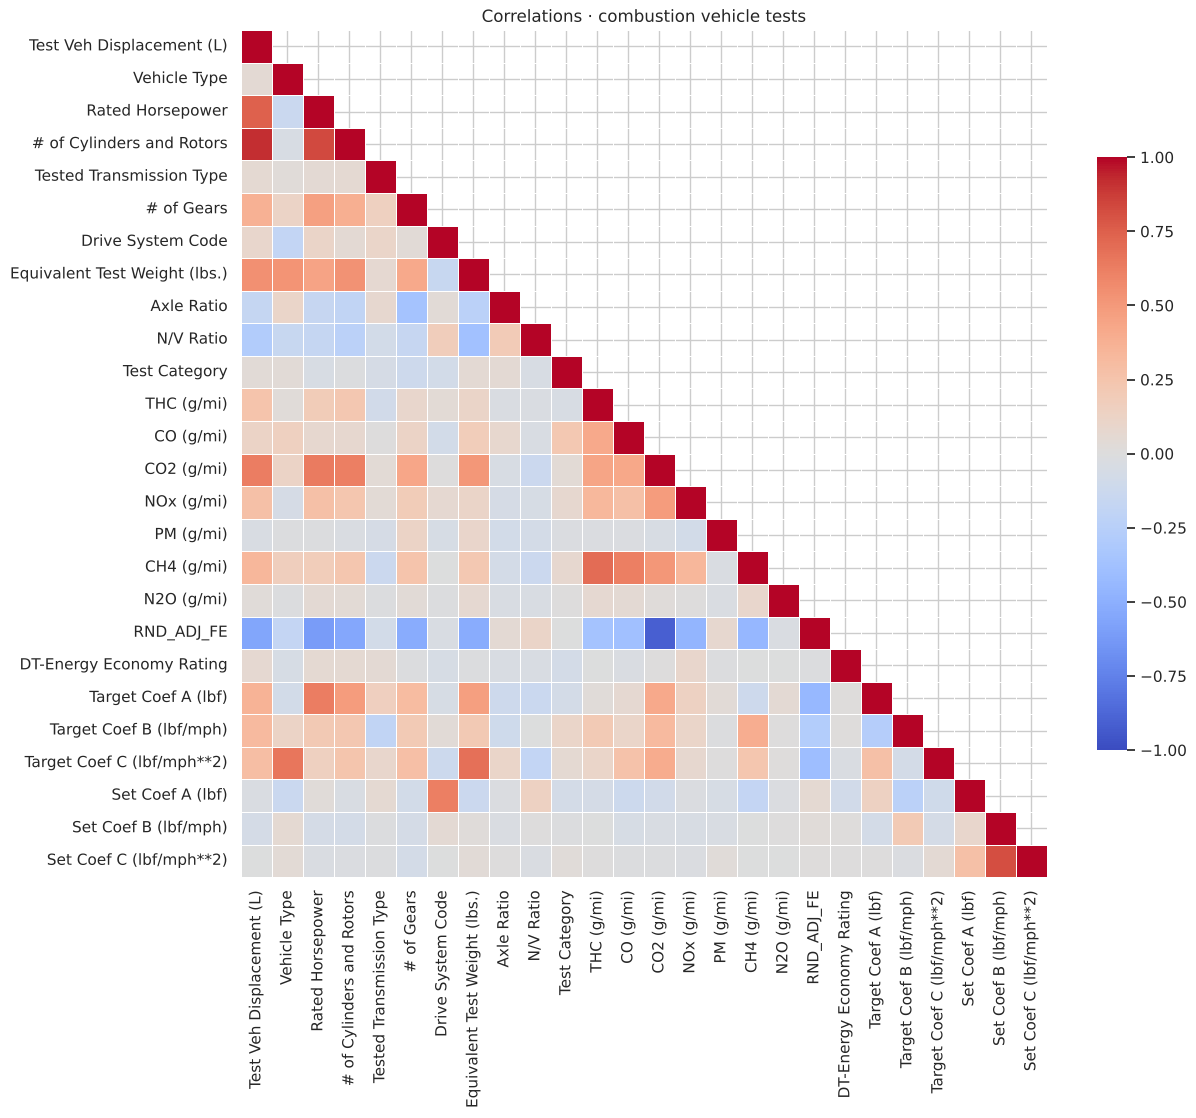

,Most positive,Most negative
0,Test Veh Displacement (L) ↔ # of Cylinders and...,CO2 (g/mi) ↔ RND_ADJ_FE: -0.908
1,Rated Horsepower ↔ # of Cylinders and Rotors: ...,Rated Horsepower ↔ RND_ADJ_FE: -0.610
2,Set Coef B (lbf/mph) ↔ Set Coef C (lbf/mph**2)...,Test Veh Displacement (L) ↔ RND_ADJ_FE: -0.555
3,Test Veh Displacement (L) ↔ Rated Horsepower: ...,# of Cylinders and Rotors ↔ RND_ADJ_FE: -0.552
4,THC (g/mi) ↔ CH4 (g/mi): 0.703,# of Gears ↔ RND_ADJ_FE: -0.522
5,Equivalent Test Weight (lbs.) ↔ Target Coef C ...,Equivalent Test Weight (lbs.) ↔ RND_ADJ_FE: -0...
6,Vehicle Type ↔ Target Coef C (lbf/mph**2): 0.659,NOx (g/mi) ↔ RND_ADJ_FE: -0.466
7,Rated Horsepower ↔ CO2 (g/mi): 0.637,CH4 (g/mi) ↔ RND_ADJ_FE: -0.450


In [7]:
enc_cols = ["Vehicle Type", "Tested Transmission Type", "Drive System Code", "Test Category"]
corr_df = comb.drop(columns=["Vehicle ID", "Test Fuel Type Cd", "Aftertreatment Device Cd"]).copy()
corr_df[enc_cols] = OrdinalEncoder().fit_transform(corr_df[enc_cols].astype(str))
corr_c = plot_correlation(corr_df, title="Correlations · combustion vehicle tests", annot=False,
                          figsize=(13, 11), save_as="04_correlation_combustion.png")
plt.show()
top_correlations(corr_c, 8)

In [8]:
NUM_C = ["Target Coef A (lbf)", "Target Coef B (lbf/mph)", "Target Coef C (lbf/mph**2)", "Test Veh Displacement (L)",
         "Equivalent Test Weight (lbs.)", "# of Gears", "Axle Ratio", "Rated Horsepower"]
CAT_C = ["Vehicle Type", "Test Category"]
C = comb[NUM_C + CAT_C + ["RND_ADJ_FE", "CO2 (g/mi)", "Vehicle ID"]].dropna().reset_index(drop=True)
idx_tr, idx_te = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE).split(C, groups=C["Vehicle ID"]))
assert not set(C.loc[idx_tr, "Vehicle ID"]) & set(C.loc[idx_te, "Vehicle ID"])
print(f"{len(C)} complete tests · test split: {len(idx_te)} tests of unseen vehicles")

results = []
def run(name, model, feats, target, data=C, tr=idx_tr, te=idx_te):
    r = evaluate_regressor(name, model, data.loc[tr, feats], data.loc[te, feats], data.loc[tr, target],
                           data.loc[te, target], data[feats], data[target], groups=data["Vehicle ID"])
    r["_y_test"] = data.loc[te, target].to_numpy()
    results.append(r)
    return r

def pipe(est, ordinal=False):
    cat = OrdinalEncoder() if ordinal else OneHotEncoder(handle_unknown="ignore")
    return Pipeline([("pre", ColumnTransformer([("num", MinMaxScaler(), NUM_C), ("cat", cat, CAT_C)])), ("model", est)])

def gb():
    return GradientBoostingRegressor(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                                     random_state=RANDOM_STATE)

3137 complete tests · test split: 729 tests of unseen vehicles


### 2.1 Per-cycle fuel economy (mpg)

The cycle has no natural order (FTP, HWY, SC03, US06): encoding it as a number forces the linear model to assume that
each cycle consumes "a little more" than the previous one. This is compared explicitly against one-hot encoding.

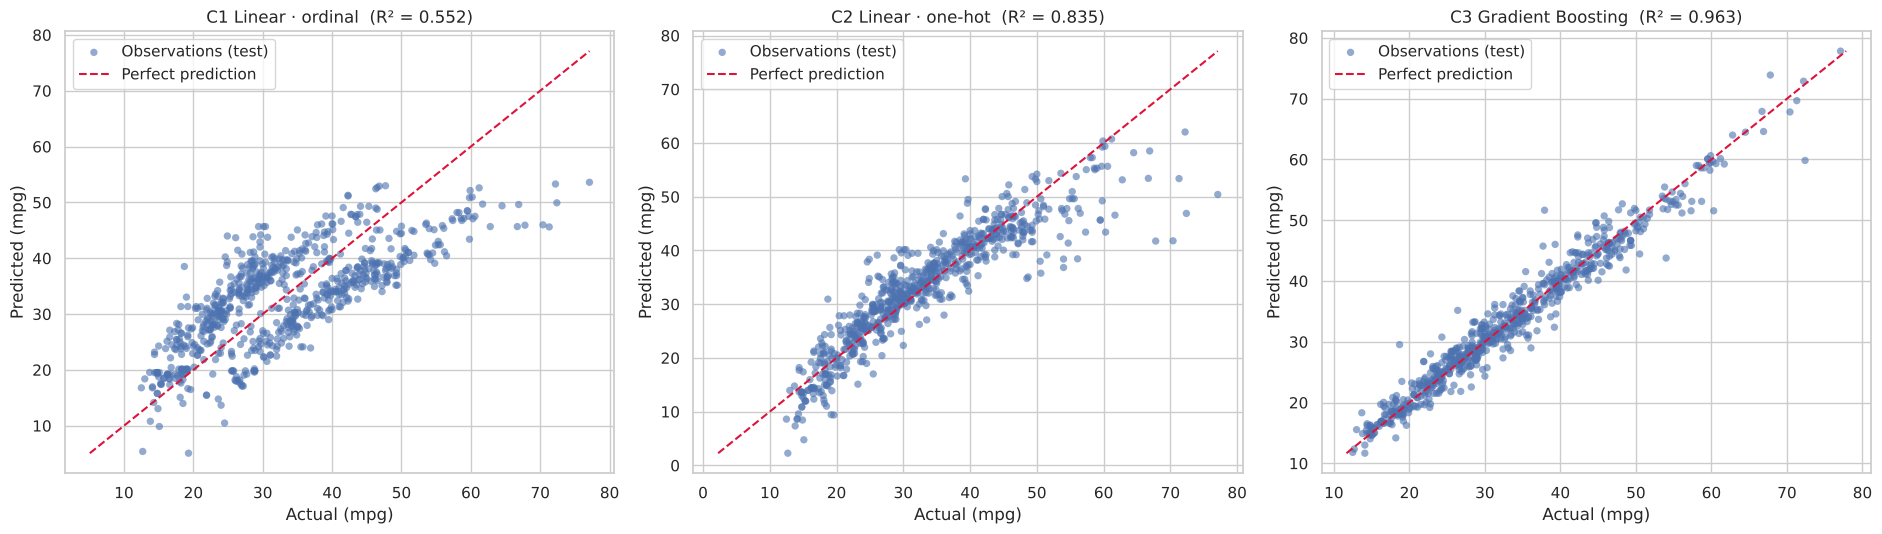

In [9]:
run("C0 Baseline · mean", pipe(DummyRegressor()), NUM_C + CAT_C, "RND_ADJ_FE")
r1 = run("C1 Linear · ordinal cycle", pipe(LinearRegression(), ordinal=True), NUM_C + CAT_C, "RND_ADJ_FE")
r2 = run("C2 Linear · one-hot cycle", pipe(LinearRegression()), NUM_C + CAT_C, "RND_ADJ_FE")
r3 = run("C3 Gradient Boosting · one-hot cycle", pipe(gb()), NUM_C + CAT_C, "RND_ADJ_FE")
fig, axs = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, r, t in zip(axs, [r1, r2, r3], ["C1 Linear · ordinal", "C2 Linear · one-hot", "C3 Gradient Boosting"]):
    plot_pred_vs_real(r["_y_test"], r["_y_pred"], t, "(mpg)", ax=ax)
fig.tight_layout(); fig.savefig("../reports/figures/04_combustion_mpg.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Measured CO₂ emissions (g/mi)

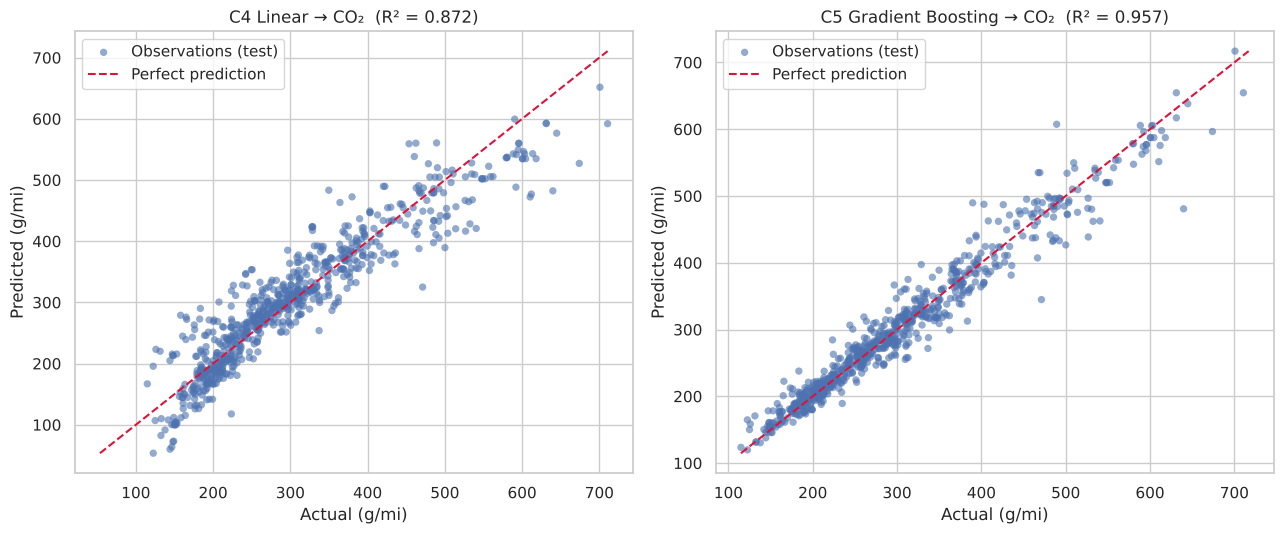

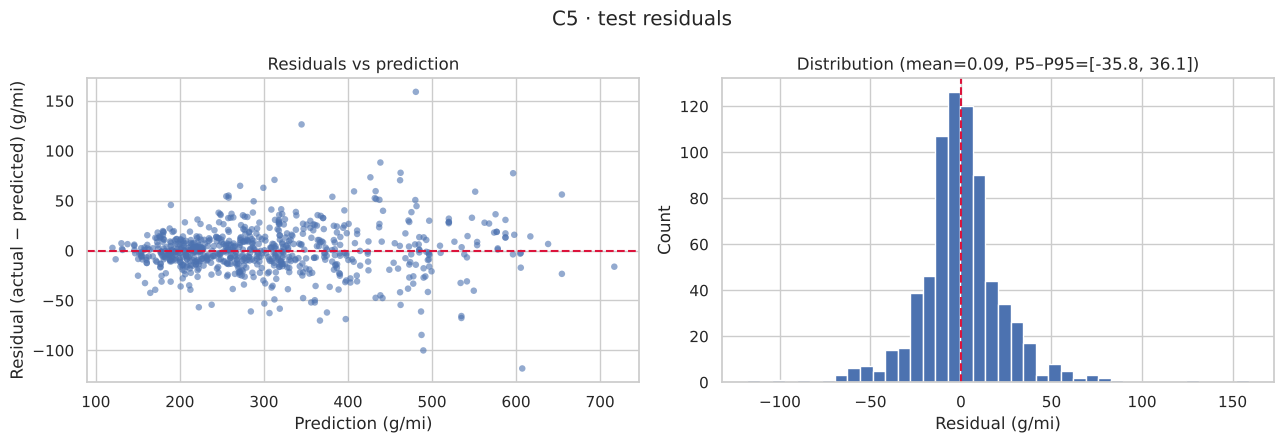

In [10]:
r4 = run("C4 Linear · one-hot → CO₂", pipe(LinearRegression()), NUM_C + CAT_C, "CO2 (g/mi)")
r5 = run("C5 Gradient Boosting · one-hot → CO₂", pipe(gb()), NUM_C + CAT_C, "CO2 (g/mi)")
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
plot_pred_vs_real(r4["_y_test"], r4["_y_pred"], "C4 Linear → CO₂", "(g/mi)", ax=axs[0])
plot_pred_vs_real(r5["_y_test"], r5["_y_pred"], "C5 Gradient Boosting → CO₂", "(g/mi)", ax=axs[1])
fig.tight_layout(); fig.savefig("../reports/figures/04_combustion_co2.png", dpi=150, bbox_inches="tight")
plt.show()
plot_residuals(r5["_y_test"], r5["_y_pred"], "(g/mi)", "C5 · test residuals", save_as="04_C5_residuals.png")
plt.show()

In [11]:
results_table(results)

,MAE,RMSE,R2,R2 CV,± std,R2 grouped CV,MAE grouped CV
Experiment,,,,,,,
C0 Baseline · mean,9.452,11.760,-0.004,-0.002,0.002,-0.005,9.520
C1 Linear · ordinal cycle,6.910,7.857,0.552,0.552,0.034,0.553,6.922
C2 Linear · one-hot cycle,3.298,4.775,0.835,0.831,0.010,0.830,3.400
C3 Gradient Boosting · one-hot cycle,1.594,2.269,0.963,0.973,0.004,0.966,1.570
C4 Linear · one-hot → CO₂,30.433,40.851,0.872,0.861,0.009,0.862,31.888
C5 Gradient Boosting · one-hot → CO₂,16.187,23.654,0.957,0.946,0.014,0.943,17.608


## 3. Electric vehicles

Tests run on electricity (code 62). They all belong to the `CD` (*charge depleting*) cycle and fuel economy is in mpge.
Features that make no sense for an electric vehicle (displacement, gears, emissions) are dropped.

508 tests · 225 vehicles · cycles with reported fuel economy: ['CD']


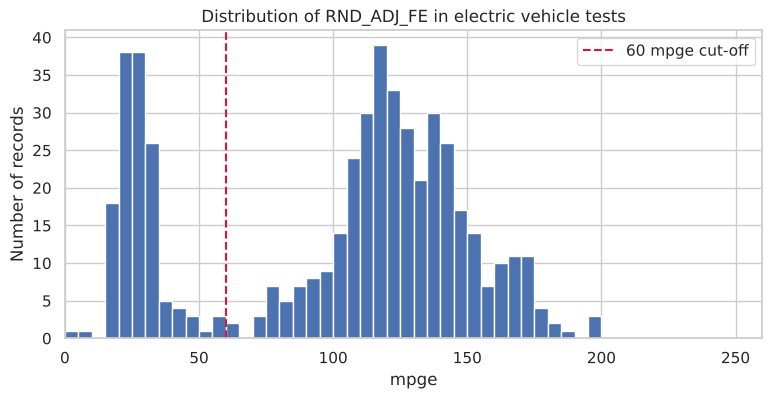

< 60 mpge: 138 · 60–250: 366 · > 250: 4


In [12]:
ev = df[df["Test Fuel Type Cd"] == 62].copy()
NUM_E = ["Target Coef A (lbf)", "Target Coef B (lbf/mph)", "Target Coef C (lbf/mph**2)", "Rated Horsepower",
         "Equivalent Test Weight (lbs.)"]
CAT_E = ["Vehicle Type"]
E = ev[NUM_E + CAT_E + ["RND_ADJ_FE", "Vehicle ID"]].dropna().reset_index(drop=True)
print(f"{len(E)} tests · {E['Vehicle ID'].nunique()} vehicles · "
      f"cycles with reported fuel economy: {ev.loc[ev['RND_ADJ_FE'].notna(), 'Test Category'].unique().tolist()}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(E["RND_ADJ_FE"], bins=np.arange(0, 260, 5), color="#4C72B0")
ax.axvline(60, color="crimson", ls="--", label="60 mpge cut-off")
ax.set(title="Distribution of RND_ADJ_FE in electric vehicle tests", xlabel="mpge", ylabel="Number of records", xlim=(0, 260))
ax.legend(); fig.savefig("../reports/figures/04_ev_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"< 60 mpge: {(E['RND_ADJ_FE'] < 60).sum()} · 60–250: {E['RND_ADJ_FE'].between(60, 250).sum()} · > 250: {(E['RND_ADJ_FE'] > 250).sum()}")

The distribution is **bimodal**: a main group between 80 and 200 mpge (typical EV consumption) and another below 60
that corresponds to a different record type within the same cycle. No available feature separates the two groups,
so the model is evaluated on all records and restricted to the main group.

In [13]:
def ev_pipe(est):
    return Pipeline([("pre", ColumnTransformer([("num", MinMaxScaler(), NUM_E),
                                                ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_E)])), ("model", est)])

ev_results = []
for label, data in [("all records", E), ("main group 60–250 mpge", E[E["RND_ADJ_FE"].between(60, 250)].reset_index(drop=True))]:
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE).split(data, groups=data["Vehicle ID"]))
    for mname, est in [("Linear", LinearRegression()),
                       ("Gradient Boosting", GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                                                      subsample=0.8, random_state=RANDOM_STATE))]:
        r = evaluate_regressor(f"EV {mname} · {label}", ev_pipe(est), data.loc[tr, NUM_E + CAT_E], data.loc[te, NUM_E + CAT_E],
                               data.loc[tr, "RND_ADJ_FE"], data.loc[te, "RND_ADJ_FE"], data[NUM_E + CAT_E],
                               data["RND_ADJ_FE"], groups=data["Vehicle ID"])
        r["_y_test"] = data.loc[te, "RND_ADJ_FE"].to_numpy()
        ev_results.append(r)
ev_table = results_table(ev_results)
ev_table

,MAE,RMSE,R2,R2 CV,± std,R2 grouped CV,MAE grouped CV
Experiment,,,,,,,
EV Linear · all records,39.221,55.185,-0.342,0.012,0.055,-1.083,46.619
EV Gradient Boosting · all records,26.354,39.575,0.310,0.823,0.136,0.276,30.177
EV Linear · main group 60–250 mpge,10.887,13.504,0.673,0.575,0.124,-0.217,14.006
EV Gradient Boosting · main group 60–250 mpge,10.985,14.205,0.638,0.670,0.081,0.665,10.511


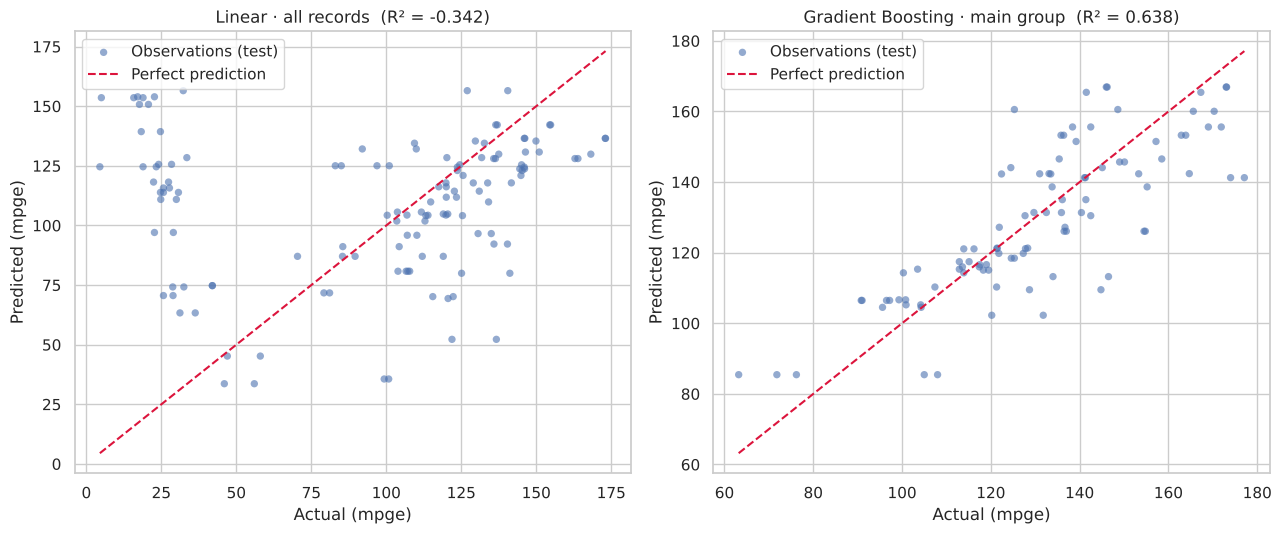

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
plot_pred_vs_real(ev_results[0]["_y_test"], ev_results[0]["_y_pred"], "Linear · all records", "(mpge)", ax=axs[0])
plot_pred_vs_real(ev_results[3]["_y_test"], ev_results[3]["_y_pred"], "Gradient Boosting · main group", "(mpge)", ax=axs[1])
fig.tight_layout(); fig.savefig("../reports/figures/04_electric_vehicles.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Conclusions

* **Data quality is a prerequisite, not a detail.** 22 records with non-physical markers (999, 10,000) had a variance
  thousands of times larger than the rest and were enough to invalidate any squared-error metric. The
  `validate_epa_test_cars` contract blocks them before modeling.
* **Test-bench quantities explain almost all of a combustion vehicle's fuel economy.** With equivalent test weight,
  road-load coefficients, displacement, power and cycle, Gradient Boosting reaches **R² ≈ 0.97 on mpg and ≈ 0.94 on
  CO₂** for unseen vehicles, with a mean error of ≈ 1.6 mpg and ≈ 18 g/mi.
* **Encoding a single variable correctly changes the outcome:** switching the cycle from ordinal to one-hot raises
  the linear R² from 0.55 to 0.83, because cycles have no natural order.
* **For electric vehicles, random validation is misleading.** Each vehicle appears several times; with `KFold`,
  Gradient Boosting scores R² ≈ 0.82, but with `GroupKFold` by vehicle it drops to ≈ 0.28: the model was memorizing
  vehicles, not learning physics. Restricted to the main record group (60–250 mpge), the honest estimate is R² ≈ 0.67
  with a mean error of ≈ 10.5 mpge.
* **Next step for EVs:** add battery capacity and chemistry, drivetrain efficiency and the record type within the
  `CD` cycle; without them, road-load features explain only part of the variability.